# Can we predict level of polluation from meteorological data?

# Import libraries
This section imports the Python libraries you will need for completing question 1.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import pandas as pd
import math
import statistics

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


import tensorflow as tf
import tensorflow_datasets as tfds

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

import os
import json

from tensorflow import keras
from keras.layers import InputLayer
from keras.layers import Dense
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.layers import Dropout
from keras.utils.np_utils import to_categorical

from sklearn.model_selection import StratifiedShuffleSplit



# Data and datasets


An [Air quality dataset](https://www.kaggle.com/datasets/avibagul80/air-quality-dataset) has been chosen for comparing and constrasting the effectiveness of neural network and alternative approaches to predicting and classifying air pollution. The dataset contains some observations in relation to time, weather, air pollution (pm2.5) values collected from some sense-boxes installed in 14 locations scattered in Frankfurt, Germany. Those observations were captured within a period of approximately 14 months; i.e., 31/12/2018 and 28/02/2020.

More information about the datasets and can be found in Kaggle; [Air quality dataset](https://www.kaggle.com/datasets/avibagul80/air-quality-dataset) 



## Datasets
We load the training and testing data into a pandas dataframe. The data is stored the file _data/preprocessed_data.csv_. The function named __upload_data__ load the data into a dataframe and return a relevant subset of data. The latter are:

* __temperatures__
* __pressure__
* __humidity__
* __wind speed__
* __peak or no peak__: 0: 'Peak', 1: 'No_Peak'
* __time of day__ : 0: 'Evening_Hours', 1: 'Night_Hours', 2: 'Morning_Hours', 3: 'Afternoon_Hours'
* __day__ : 0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
* __week day__ : 0: 'Workday', 1: 'Weekend'
* __weather__ : 0: 'Clouds',
  1: 'Mist',
  2: 'Fog',
  3: 'Rain',
  4: 'Drizzle',
  5: 'Drizzle + Rain',
  6: 'Clear',
  7: 'Snow',
  8: 'Snow + Mist',
  9: 'Drizzle + Snow + Mist',
  10: 'Drizzle + Rain + Mist',
  11: 'Drizzle + Mist',
  12: 'Rain + Snow',
  13: 'Rain + Mist',
  14: 'Mist + Fog',
  15: 'Thunderstorm + Rain',
  16: 'Squall',
  17: 'Haze',
  18: 'Thunderstorm',
  19: 'Thunderstorm + Squall',
  20: 'Rain + Fog',
  21: 'Snow + Mist + Fog',
  22: 'Snow + Fog'}
* __lattitude__
* __longitude__
* __pm 2.5 level__: see explanation below 

The PM 2.5 level is a categorical data based on the following classification rules, where 1 is the lowest risks to increase risk pulmonary disease and long-term mortality risk and 5 the highest risks.

* If (PM 2.5 >= 0)  and (PM 2.5 <= 10), then PM 2.5 level = 1
* If (PM 2.5 > 10)  and (PM 2.5 <= 15), then PM 2.5 level = 2
* If (PM 2.5 > 15)  & (PM 2.5 <= 25), then PM 2.5 level = 3
* If (PM 2.5 > 25)  & (PM 2.5' <= 35), then PM 2.5 level = 4
* if (PM 2.5 > 35), then 'PM 2.5 level = 5

More information on each column and meta data can be found in an be found in Kaggle; [Air quality dataset](https://www.kaggle.com/datasets/avibagul80/air-quality-dataset). Some 




In [2]:
def upload_data():
    data = pd.read_csv('data/processed_data.csv')
    data = data[['temp','pressure','humidity','wind_speed', 'Time of Day',
          'Peak/NoPeak','Day','Week Day','Weather',
          'latitude', 'longitude','PM 2.5 level num']]
    return data

The dataset has some values varying in units and others in thousand. We normalise the values to reduce the gap in values and support the learning approaches. The function __normalise_data__ divide each columns value of a column by the mean of the column.

In [3]:
def normalise_data(data):
    data.loc[:,'temp'] = data['temp']/statistics.mean(data['temp'])
    data.loc[:,'pressure'] = data['pressure']/statistics.mean(data['pressure'])
    data.loc[:,'humidity'] = data['humidity']/statistics.mean(data['humidity'])
    data.loc[:,'wind_speed'] = data['wind_speed']/statistics.mean(data['wind_speed'])
    data.loc[:,'Peak/NoPeak'] = data['Peak/NoPeak']/statistics.mean(data['Peak/NoPeak'])
    data.loc[:,'Day'] = data['Day']/statistics.mean(data['Day'])
    data.loc[:,'Week Day'] = data['Week Day']/statistics.mean(data['Week Day'])
    data.loc[:,'Weather'] = data['Weather']/statistics.mean(data['Weather'])
    data.loc[:,'Time of Day'] = data['Time of Day']/statistics.mean(data['Time of Day'])
    return data

The dataset is divided into three subsets; i.e, X_train, X_valid and X_test. For each of these subsets some categories of air pollution is provided. The function named __split_datasets__ divide the datasets using a stratified method. As a results, each subset should have a similar distribution of values  across  each subset. It should support learning.

In [4]:
def split_datasets(data):
    # select data for analysis as X and Y datasets
    X = data.iloc[:,:-1]
    y = data['PM 2.5 level num']
    #Split dataset into training and testing
    split = StratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
    for train_index, test_valid_index in split.split(X, y):
        X_train = X.iloc[train_index]
        y_train = y.iloc[train_index]
        X_test  = X.iloc[test_valid_index]
        y_test  = y.iloc[test_valid_index]
    # Split test and validation data set.
    split_test_valid = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    for test_index, valid_index in split_test_valid.split(X_test, y_test):
        X_valid = X_test.iloc[valid_index]
        y_valid = y_test.iloc[valid_index]
        X_test  = X_test.iloc[test_index]
        y_test  = y_test.iloc[test_index]
    return X_train, y_train, X_valid, y_valid, X_test, y_test 
    

In [5]:
# Upload the data 
data = upload_data()
data = normalise_data(data)
X_train, y_train, X_valid, y_valid, X_test, y_test = split_datasets(data)
y_train_encode=pd.get_dummies(y_train)
y_test_encode=pd.get_dummies(y_test)
y_valid_encode=pd.get_dummies(y_valid)
n_cols=X_train.shape[1]
n_cols



11

In [6]:
y_test_encode.sum()

1.0    144476
2.0     24116
3.0     21443
4.0      7114
5.0      3442
dtype: int64

# Artificial Neural network

## Create a model

The model is based on the idea that a dropout layer should combat the imbalanced number of air quality observations of good quality (category 1).  Then, the number of layers is being reduced by half. The sigmoid activation has been chosen in the first layers. but some relu activations have been chosen to attempt to combat a vanishing gradient. The last layer has an activation set to _softmax_; the latter scale them between 0 and 1 in a distribution against each category.

The "Adam" optimiser was chosen, as it offers more non-deterministic optimisation during the model fitting. We chose the accuracy metrics to compare with the alternative approaches.

In [7]:
model=Sequential()
model.add(InputLayer(input_shape=(n_cols, ), name='Input_Layer'))
model.add(Dropout(0.2, input_shape=(10,)))
model.add(Dense(1024,activation='sigmoid'))
model.add(Dense(512,activation='sigmoid'))
model.add(Dense(256,activation='relu'))
model.add(Dense(5,activation='softmax'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dropout (Dropout)            (None, 11)                0         
_________________________________________________________________
dense (Dense)                (None, 1024)              12288     
_________________________________________________________________
dense_1 (Dense)              (None, 512)               524800    
_________________________________________________________________
dense_2 (Dense)              (None, 256)               131328    
_________________________________________________________________
dense_3 (Dense)              (None, 5)                 1285      
Total params: 669,701
Trainable params: 669,701
Non-trainable params: 0
_________________________________________________________________


## Train the model

Train the model using 30 epochs. Each epoch may take 5 minutes. It is worth setting aside between 3 to 4 hours to run train and cross-validate the whole models on the GPU. 

In [8]:
history = model.fit(X_train, 
                    y_train_encode, 
                    validation_data=(X_valid, y_valid_encode),
                    epochs=30, 
                    batch_size=5)

Epoch 1/30
120355/120355 [==============================] - 285s 2ms/step - loss: 0.2747 - accuracy: 0.7264 - val_loss: 0.2635 - val_accuracy: 0.7346
Epoch 2/30
120355/120355 [==============================] - 283s 2ms/step - loss: 0.2649 - accuracy: 0.7331 - val_loss: 0.2586 - val_accuracy: 0.7385
Epoch 3/30
120355/120355 [==============================] - 281s 2ms/step - loss: 0.2627 - accuracy: 0.7346 - val_loss: 0.2493 - val_accuracy: 0.7409
Epoch 4/30
120355/120355 [==============================] - 283s 2ms/step - loss: 0.2610 - accuracy: 0.7353 - val_loss: 0.2507 - val_accuracy: 0.7419
Epoch 5/30
120355/120355 [==============================] - 282s 2ms/step - loss: 0.2598 - accuracy: 0.7358 - val_loss: 0.2439 - val_accuracy: 0.7427
Epoch 6/30
120355/120355 [==============================] - 283s 2ms/step - loss: 0.2590 - accuracy: 0.7358 - val_loss: 0.2437 - val_accuracy: 0.7435
Epoch 7/30
120355/120355 [==============================] - 277s 2ms/step - loss: 0.2579 - accuracy:

## Save the model 

Save the model and history. Some warning messages may be displayed and needs ignoring.

In [9]:
model.save('ann_model.h5')

with open('ann_history.json', 'w') as f:
    json.dump(history.history, f)


INFO:tensorflow:Assets written to: ann_model/assets


INFO:tensorflow:Assets written to: ann_model/assets


## history visualisation

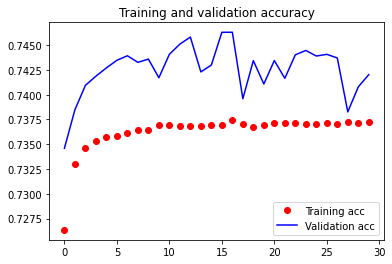

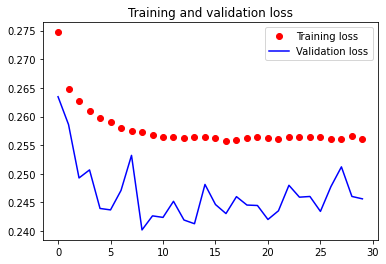

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'ro', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'ro', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## Evaluate model against the validation set

In [16]:
_, accuracy = model.evaluate(X_valid, y_valid_encode)
print('Accuracy: %.4f' % (accuracy*100))

6269/6269 [==============================] - 9s 1ms/step - loss: 0.2456 - accuracy: 0.7420
Accuracy: 74.2022


## Validate the model against the test dataset

In [17]:
#Evaluate/Confution Matrix and Classification Report
y_pred = model.predict(X_test)



In [26]:

correct_pred = (y_pred * y_test_encode).sum()
correct_pred = correct_pred/y_test_encode.sum()
correct_pred

1.0    0.905523
2.0    0.114107
3.0    0.182289
4.0    0.159168
5.0    0.164807
dtype: float64

__Evaluation:__

The neural network has classified suitably for the good air quality, which has the majority of the observations. It has yet to predict suitably for the other categories.

# Encoders  to simplify data

You will need to execute this code to complete a cross-validation. It may take quite a long time. So we would recommend you to execute notebook over a period of 12 hours.